<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 47.0 MB/s eta 0:00:00


In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    # 1. Convertir le texte en minuscules et tokeniser le texte
    # Convertit tout le texte en minuscules pour assurer l'uniformité et le tokenise en mots.
    tokens = nltk.word_tokenize(text.lower())

    # 2. Supprimer la ponctuation
    # Crée une liste de tokens en excluant ceux qui sont des signes de ponctuation.
    tokens = [token for token in tokens if token not in string.punctuation]

    # 3. Supprimer les mots vides (stopwords)
    # Filtre les mots communs (stopwords) qui n'ajoutent pas de sens significatif au texte.
    tokens = [token for token in tokens if token not in stop_words]

    # 4. Appliquer un lemmatiseur
    # Réduit chaque mot à sa forme de base (lemme), par exemple 'running' devient 'run'.
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # 5. Retourner la chaîne de texte prétraitée rejointe par des espaces
    # Rejoint les tokens lemmatisés pour former une chaîne de texte propre.
    return " ".join(lemmatized_tokens)

In [5]:
import pandas as pd

# Appliquer preprocess_text à chaque critique et stocker les résultats
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# Afficher le texte avant et après nettoyage pour vérification
print("Comparaison des critiques brutes et prétraitées :")
for i, (raw, cleaned) in enumerate(zip(raw_reviews, cleaned_reviews)):
    print(f"--- Critique {i+1} ---")
    print(f"Brute:     {raw}")
    print(f"Nettoyée: {cleaned}\n")

Comparaison des critiques brutes et prétraitées :
--- Critique 1 ---
Brute:     At McDonald's the food was ok and the service was bad.
Nettoyée: mcdonald 's food ok service bad

--- Critique 2 ---
Brute:     I would not recommend this Japanese restaurant to anyone.
Nettoyée: would recommend japanese restaurant anyone

--- Critique 3 ---
Brute:     I loved this restaurant when I traveled to Thailand last summer.
Nettoyée: loved restaurant traveled thailand last summer

--- Critique 4 ---
Brute:     The menu of Loving has a wide variety of options.
Nettoyée: menu loving wide variety option

--- Critique 5 ---
Brute:     The staff was friendly and helpful at Google's employees restaurant.
Nettoyée: staff friendly helpful google 's employee restaurant

--- Critique 6 ---
Brute:     The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
Nettoyée: ambiance bella italia amazing pasta dish delicious

--- Critique 7 ---
Brute:     I had a terrible experience at Pizza Hut. 

In [6]:
# Créer un DataFrame pandas avec les critiques brutes et prétraitées
df_reviews = pd.DataFrame({
    'Review': raw_reviews,
    'Clean_Review': cleaned_reviews
})

# Afficher le DataFrame
print("DataFrame contenant les critiques brutes et nettoyées :")
display(df_reviews.head())

DataFrame contenant les critiques brutes et nettoyées :


,Review,Clean_Review
0,At McDonald's the food was ok and the service ...,mcdonald 's food ok service bad
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer
3,The menu of Loving has a wide variety of options.,menu loving wide variety option
4,The staff was friendly and helpful at Google's...,staff friendly helpful google 's employee rest...


### Explication de la conservation des deux versions (brute et nettoyée)

Il est souvent très utile de conserver à la fois les données brutes et les données prétraitées pour plusieurs raisons :

*   **Comparaison et vérification** : Permet de comparer facilement l'impact du prétraitement sur les données originales. On peut ainsi s'assurer que les étapes de nettoyage n'ont pas introduit d'erreurs ou supprimé des informations cruciales par inadvertance.
*   **Analyse contextuelle** : Pour certaines tâches, le contexte original du texte (ponctuation, majuscules, mots vides) peut être pertinent. Par exemple, pour l'analyse des sentiments, les majuscules ou les points d'exclamation peuvent indiquer une émotion forte.
*   **Flexibilité pour d'autres tâches** : Différentes tâches de NLP peuvent nécessiter différents niveaux ou types de prétraitement. En conservant la version brute, on peut toujours revenir en arrière et appliquer un autre ensemble de règles de nettoyage sans perdre l'information originale.
*   **Interprétabilité** : Lorsque l'on interprète les résultats d'un modèle entraîné sur du texte nettoyé, il est souvent plus facile de relier ces résultats au texte original pour une meilleure compréhension humaine.

### 1.3 Named Entity Recognition (NER)

Nous allons maintenant compléter la fonction `perform_ner()` pour extraire les entités nommées à l'aide de spaCy (`en_core_web_sm`). Après avoir implémenté la fonction, nous l'appliquerons aux critiques brutes et nettoyées pour observer les différences.

### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [7]:
# Apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

# The raise ValueError line is no longer needed as cleaned_reviews will always be set.
# The loop to print raw and cleaned reviews is already correct and will now execute.
for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")

RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

In [8]:
import pandas as pd

# Créer un DataFrame pandas avec les critiques brutes et prétraitées
df_reviews = pd.DataFrame({
    'Review': raw_reviews,
    'Clean_Review': cleaned_reviews
})

# Afficher le DataFrame
print("DataFrame contenant les critiques brutes et nettoyées :")
display(df_reviews.head())

DataFrame contenant les critiques brutes et nettoyées :


,Review,Clean_Review
0,At McDonald's the food was ok and the service ...,mcdonald 's food ok service bad
1,I would not recommend this Japanese restaurant...,would recommend japanese restaurant anyone
2,I loved this restaurant when I traveled to Tha...,loved restaurant traveled thailand last summer
3,The menu of Loving has a wide variety of options.,menu loving wide variety option
4,The staff was friendly and helpful at Google's...,staff friendly helpful google 's employee rest...


### Explication de la conservation des deux versions (brute et nettoyée)

Il est souvent très utile de conserver à la fois les données brutes et les données prétraitées pour plusieurs raisons :

*   **Comparaison et vérification** : Permet de comparer facilement l'impact du prétraitement sur les données originales. On peut ainsi s'assurer que les étapes de nettoyage n'ont pas introduit d'erreurs ou supprimé des informations cruciales par inadvertance.
*   **Analyse contextuelle** : Pour certaines tâches, le contexte original du texte (ponctuation, majuscules, mots vides) peut être pertinent. Par exemple, pour l'analyse des sentiments, les majuscules ou les points d'exclamation peuvent indiquer une émotion forte.
*   **Flexibilité pour d'autres tâches** : Différentes tâches de NLP peuvent nécessiter différents niveaux ou types de prétraitement. En conservant la version brute, on peut toujours revenir en arrière et appliquer un autre ensemble de règles de nettoyage sans perdre l'information originale.
*   **Interprétabilité** : Lorsque l'on interprète les résultats d'un modèle entraîné sur du texte nettoyé, il est souvent plus facile de relier ces résultats au texte original pour une meilleure compréhension humaine.

### 1.3 Named Entity Recognition (NER)

Nous allons maintenant compléter la fonction `perform_ner()` pour extraire les entités nommées à l'aide de spaCy (`en_core_web_sm`). Après avoir implémenté la fonction, nous l'appliquerons aux critiques brutes et nettoyées pour observer les différences.

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [9]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # Appliquer le pipeline spaCy sur le texte
    doc = nlp(text)
    # Collecter chaque texte d'entité et son étiquette
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

In [10]:
# Appliquer perform_ner aux données brutes et afficher les résultats
print("\n--- NER sur les données brutes ---")
ner_raw_results = []
for i, review in enumerate(raw_reviews):
    ner_entities = perform_ner(review)
    ner_raw_results.append(ner_entities)
    print(f"Critique {i+1} (Brute): {review}")
    print(f"Entités NER: {ner_entities}\n")

# Appliquer perform_ner aux données prétraitées et afficher les résultats
print("\n--- NER sur les données prétraitées ---")
ner_cleaned_results = []
for i, review in enumerate(cleaned_reviews):
    ner_entities = perform_ner(review)
    ner_cleaned_results.append(ner_entities)
    print(f"Critique {i+1} (Nettoyée): {review}")
    print(f"Entités NER: {ner_entities}\n")

# Afficher les résultats dans un tableau (DataFrame) pour une meilleure lisibilité
ner_comparison_df = pd.DataFrame({
    'Review': raw_reviews,
    'NER_Raw': ner_raw_results,
    'Clean_Review': cleaned_reviews,
    'NER_Cleaned': ner_cleaned_results
})
print("Comparaison des résultats NER sur texte brut vs. nettoyé :")
display(ner_comparison_df)


--- NER sur les données brutes ---
Critique 1 (Brute): At McDonald's the food was ok and the service was bad.
Entités NER: [('McDonald', 'ORG')]

Critique 2 (Brute): I would not recommend this Japanese restaurant to anyone.
Entités NER: [('Japanese', 'NORP')]

Critique 3 (Brute): I loved this restaurant when I traveled to Thailand last summer.
Entités NER: [('Thailand', 'GPE'), ('last summer', 'DATE')]

Critique 4 (Brute): The menu of Loving has a wide variety of options.
Entités NER: [('Loving', 'GPE')]

Critique 5 (Brute): The staff was friendly and helpful at Google's employees restaurant.
Entités NER: [('Google', 'ORG')]

Critique 6 (Brute): The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
Entités NER: [('Bella Italia', 'ORG')]

Critique 7 (Brute): I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
Entités NER: [('Pizza Hut', 'ORG')]

Critique 8 (Brute): The sushi at Sushi Express is always fresh and flavorful.
Enti

,Review,NER_Raw,Clean_Review,NER_Cleaned
0,At McDonald's the food was ok and the service ...,"[(McDonald, ORG)]",mcdonald 's food ok service bad,"[(mcdonald 's food ok service, ORG)]"
1,I would not recommend this Japanese restaurant...,"[(Japanese, NORP)]",would recommend japanese restaurant anyone,"[(japanese, NORP)]"
2,I loved this restaurant when I traveled to Tha...,"[(Thailand, GPE), (last summer, DATE)]",loved restaurant traveled thailand last summer,"[(thailand, GPE), (last summer, DATE)]"
3,The menu of Loving has a wide variety of options.,"[(Loving, GPE)]",menu loving wide variety option,[]
4,The staff was friendly and helpful at Google's...,"[(Google, ORG)]",staff friendly helpful google 's employee rest...,"[(google, ORG)]"
5,"The ambiance at Bella Italia is amazing, and t...","[(Bella Italia, ORG)]",ambiance bella italia amazing pasta dish delic...,"[(ambiance bella italia, PERSON)]"
6,I had a terrible experience at Pizza Hut. The ...,"[(Pizza Hut, ORG)]",terrible experience pizza hut pizza burnt serv...,[]
7,The sushi at Sushi Express is always fresh and...,"[(Sushi Express, ORG)]",sushi sushi express always fresh flavorful,[]
8,The steakhouse on Main Street has a cozy atmos...,"[(Main Street, FAC)]",steakhouse main street cozy atmosphere excelle...,[]
9,The dessert selection at Sweet Treats is to di...,"[(Sweet Treats, PERSON)]",dessert selection sweet treat die,[]


### Explication des différences observées pour le NER

En comparant les résultats du NER sur les textes bruts et les textes nettoyés, on observe plusieurs différences significatives :

1.  **Reconnaissance d'entités plus riche sur le texte brut** : Les modèles NER, comme spaCy, sont généralement entraînés sur des textes bruts et non prétraités. Ils s'appuient sur des caractéristiques telles que la casse des lettres (majuscules/minuscules), la ponctuation, et la présence de mots vides (stopwords) pour identifier les entités. Par exemple, 'McDonald's', 'Google's', 'Bella Italia', 'Pizza Hut', 'Sushi Express', 'Main Street', 'Sweet Treats' sont correctement identifiés comme des entités `ORG` (organisation), `GPE` (lieu) ou `LOC` (location) dans le texte brut.

2.  **Perte d'informations avec le prétraitement** : Lorsque le texte est converti en minuscules, que la ponctuation est supprimée, et que les stopwords sont retirés, de nombreuses indices contextuels sont perdus. 'McDonald's' devient 'mcdonald', 'Google's' devient 'google'. Ces transformations peuvent rendre difficile pour le modèle NER de reconnaître ces mots comme des entités nommées. Par conséquent, on observe souvent une diminution du nombre d'entités détectées, ou une détection incorrecte, sur le texte nettoyé.

3.  **Impact de la lemmatisation et de la suppression des stopwords** : La lemmatisation réduit les mots à leur forme de base (par exemple, 'traveled' devient 'travel'). Si un nom propre est lemmatisé ou si un mot important pour la reconnaissance d'une entité est un stopword et est supprimé, l'entité peut ne plus être identifiée. Par exemple, 'Main Street' pourrait être difficile à détecter si 'Street' est traité différemment après prétraitement.

**Conclusion** : Pour les tâches de reconnaissance d'entités nommées, il est généralement préférable d'utiliser le texte brut ou un prétraitement minimal qui préserve les caractéristiques grammaticales et structurelles (comme la casse) qui sont importantes pour l'identification des entités. Le nettoyage agressif peut améliorer les performances pour d'autres tâches comme la classification de texte, mais il est souvent contre-productif pour le NER.

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [11]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # 1. Tokeniser le texte
    # Divise le texte en une liste de mots ou de tokens.
    tokens = word_tokenize(text)
    # 2. Appeler nltk.pos_tag sur les tokens
    # Attribue une étiquette morphosyntaxique à chaque token.
    pos_tags = pos_tag(tokens)
    return pos_tags

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [12]:
sample_texts = raw_reviews[:2]

print("NER sur texte brut")
# Appliquer perform_ner sur les échantillons de texte brut
for i, text in enumerate(sample_texts):
    ner_results = perform_ner(text)
    print(f"Critique {i+1} (Brute): {text}")
    print(f"  Entités NER: {ner_results}\n")

print("\nNER sur texte nettoyé")
# Appliquer perform_ner sur les échantillons de texte nettoyé
cleaned_sample_texts = cleaned_reviews[:2]
for i, text in enumerate(cleaned_sample_texts):
    ner_results = perform_ner(text)
    print(f"Critique {i+1} (Nettoyée): {text}")
    print(f"  Entités NER: {ner_results}\n")

print("\nÉtiquettes POS sur texte brut")
# Appliquer perform_pos_tagging sur les échantillons de texte brut
for i, text in enumerate(sample_texts):
    pos_results = perform_pos_tagging(text)
    print(f"Critique {i+1} (Brute): {text}")
    print(f"  Étiquettes POS: {pos_results}\n")

print("\nÉtiquettes POS sur texte nettoyé")
# Appliquer perform_pos_tagging sur les échantillons de texte nettoyé
for i, text in enumerate(cleaned_sample_texts):
    pos_results = perform_pos_tagging(text)
    print(f"Critique {i+1} (Nettoyée): {text}")
    print(f"  Étiquettes POS: {pos_results}\n")

NER sur texte brut
Critique 1 (Brute): At McDonald's the food was ok and the service was bad.
  Entités NER: [('McDonald', 'ORG')]

Critique 2 (Brute): I would not recommend this Japanese restaurant to anyone.
  Entités NER: [('Japanese', 'NORP')]


NER sur texte nettoyé
Critique 1 (Nettoyée): mcdonald 's food ok service bad
  Entités NER: [("mcdonald 's food ok service", 'ORG')]

Critique 2 (Nettoyée): would recommend japanese restaurant anyone
  Entités NER: [('japanese', 'NORP')]


Étiquettes POS sur texte brut
Critique 1 (Brute): At McDonald's the food was ok and the service was bad.
  Étiquettes POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

Critique 2 (Brute): I would not recommend this Japanese restaurant to anyone.
  Étiquettes POS: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('

### Explication des catégories grammaticales (POS Tags)

Les étiquettes morphosyntaxiques (POS tags) fournissent des informations sur la catégorie grammaticale de chaque mot (nom, verbe, adjectif, etc.). NLTK utilise le jeu d'étiquettes Penn Treebank. Voici quelques-unes des étiquettes importantes rencontrées :

Pour comprendre la signification exacte de chaque étiquette, on peut utiliser `nltk.help.upenn_tagset()`.


In [14]:
# Téléchargement des ressources nécessaires si ce n'est pas déjà fait
nltk.download('tagsets', quiet=True)
nltk.download('tagsets_json', quiet=True)

print("Explication de l'étiquette 'NN' (Nom singulier) :")
nltk.help.upenn_tagset('NN')

# Explications de quelques étiquettes importantes :
print("\n--- Explications des étiquettes POS clés ---")
print("**NN**: Nom singulier (e.g., 'restaurant', 'food', 'service')")
print("**NNS**: Nom pluriel (e.g., 'options', 'dishes', 'steaks')")
print("**JJ**: Adjectif (e.g., 'ok', 'bad', 'delicious', 'friendly', 'helpful', 'terrible', 'fresh', 'flavorful', 'cozy', 'excellent', 'sweet')")
print("**VB**: Verbe forme de base (e.g., 'recommend', 'love', 'die')")
print("**VBD**: Verbe au passé simple (e.g., 'traveled', 'loved', 'had', 'was', 'burnt')")
print("**VBG**: Verbe au gérondif ou participe présent (e.g., 'loving')")
print("**RB**: Adverbe (e.g., 'always', 'slow', 'amazing', 'friendly', 'helpful', 'well')")
print("**IN**: Préposition ou conjonction de subordination (e.g., 'at', 'in', 'to', 'of')")
print("**DT**: Déterminant (e.g., 'the', 'this', 'a', 'an')")
print("**PRP**: Pronom personnel (e.g., 'I')")
print("**PRP$**: Pronom possessif (e.g., 'my', 'his', 'her', 'their')")

Explication de l'étiquette 'NN' (Nom singulier) :
NN: noun, common, singular or mass
    common-carrier cabbage knuckle-duster Casino afghan shed thermostat
    investment slide humour falloff slick wind hyena override subhumanity
    machinist ...

--- Explications des étiquettes POS clés ---
**NN**: Nom singulier (e.g., 'restaurant', 'food', 'service')
**NNS**: Nom pluriel (e.g., 'options', 'dishes', 'steaks')
**JJ**: Adjectif (e.g., 'ok', 'bad', 'delicious', 'friendly', 'helpful', 'terrible', 'fresh', 'flavorful', 'cozy', 'excellent', 'sweet')
**VB**: Verbe forme de base (e.g., 'recommend', 'love', 'die')
**VBD**: Verbe au passé simple (e.g., 'traveled', 'loved', 'had', 'was', 'burnt')
**VBG**: Verbe au gérondif ou participe présent (e.g., 'loving')
**RB**: Adverbe (e.g., 'always', 'slow', 'amazing', 'friendly', 'helpful', 'well')
**IN**: Préposition ou conjonction de subordination (e.g., 'at', 'in', 'to', 'of')
**DT**: Déterminant (e.g., 'the', 'this', 'a', 'an')
**PRP**: Pronom pe

### Analyse des résultats NER et POS (données brutes vs. nettoyées)

**Comparaison NER :**

*   **Pourquoi les résultats NER changent-ils ?** Les résultats NER changent de manière significative entre les textes bruts et les textes nettoyés car les modèles NER comme spaCy s'appuient fortement sur le **contexte, la casse, la ponctuation et la structure des phrases** pour identifier les entités. Lorsque le texte est converti en minuscules, la ponctuation est supprimée et les stopwords sont retirés, de nombreux indices cruciaux pour le modèle NER disparaissent. Par exemple, 'McDonald's' ou 'Pizza Hut' sont souvent identifiés grâce à leur majuscule initiale et leur format spécifique. Une fois transformés en 'mcdonald' ou 'pizza hut' (en minuscules et sans ponctuation), le modèle a beaucoup plus de mal à les reconnaître comme des entités `ORG`.
*   **Exemple concret** : 'Google\'s employees restaurant' est traité comme une entité `ORG` ('Google') dans le texte brut. Après nettoyage, 'google employee restaurant' perd le possessif et la majuscule, rendant l'identification d'une organisation beaucoup plus difficile, voire impossible pour le modèle.

**Comparaison POS :**

*   **Pourquoi les résultats POS changent-ils ?** Les résultats POS changent également, mais souvent de manière moins drastique que le NER, car l'étiquetage POS se concentre sur la fonction grammaticale des mots. Cependant, la suppression des stopwords et la lemmatisation ont un impact :
    *   **Suppression des stopwords** : Des mots comme 'the', 'a', 'was', 'and', qui ont des étiquettes POS spécifiques (DT, VBD, CC), sont retirés. Cela réduit le nombre total de tokens à étiqueter et peut légèrement modifier le contexte pour les mots restants.
    *   **Lemmatisation** : La lemmatisation ramène les mots à leur forme de base. Par exemple, si 'traveled' est étiqueté `VBD` (verbe au passé) dans le texte brut, 'travel' (sa forme lemmatisée) pourrait être étiqueté `VB` (verbe à l'infinitif). Cela peut modifier les étiquettes spécifiques de certaines formes verbales ou nominales.
    *   **Perte de ponctuation** : La ponctuation elle-même est parfois considérée comme un token avec sa propre étiquette (`.`, `,`). Sa suppression réduit le nombre de tokens.

**Quelle version est préférable selon les cas ?**

*   **Pour le NER** : Le **texte brut** est généralement préférable. Les modèles NER sont conçus pour travailler avec le texte tel qu'il apparaît naturellement, en tirant parti de toutes les caractéristiques linguistiques (casse, ponctuation, structure). Un prétraitement minimal, voire aucun, est souvent recommandé pour le NER.
*   **Pour le POS Tagging** : Le **texte brut** est également souvent préférable pour un POS tagging précis, car il conserve la structure grammaticale complète et les formes flexionnelles des mots. Cependant, un texte légèrement prétraité (par exemple, sans ponctuation mais avec la casse conservée) peut être acceptable. Pour des analyses qui se concentrent sur les lemmes, le texte nettoyé et lemmatisé est directement utile, mais les étiquettes POS obtenues après lemmatisation peuvent être moins informatives sur la forme originale du mot.
*   **Pour d'autres tâches (ex. Classification de texte, Modélisation thématique)** : Le **texte nettoyé et prétraité** (minuscules, sans ponctuation, sans stopwords, lemmatisé) est souvent bien plus efficace. Il réduit le bruit, la dimensionnalité et se concentre sur les mots porteurs de sens, ce qui peut améliorer les performances et la généralisation des modèles.

## Exercice 2 : Représentation graphique des plongements lexicaux

Nous allons maintenant passer à l'exercice 2, qui consiste à créer et visualiser des plongements lexicaux (word embeddings) à l'aide de Word2Vec.

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [15]:
from gensim.models import Word2Vec

# Tokeniser les critiques nettoyées en séparant par les espaces.
# Word2Vec attend une liste de listes de mots (sentences).
tokenized_reviews = [review.split() for review in cleaned_reviews]

# Initialiser et entraîner le modèle Word2Vec
# vector_size: dimension des vecteurs de mots.
# window: taille de la fenêtre contextuelle.
# min_count: ignore les mots rares (ici on garde tout avec 1).
# sg: 1 pour Skip-gram.
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, sg=1)

print("Modèle Word2Vec entraîné avec succès.")
print(f"Taille du vocabulaire : {len(w2v_model.wv.index_to_key)}")

# Afficher un exemple de vecteur pour 'restaurant'
if 'restaurant' in w2v_model.wv:
    print(f"\nExtrait du vecteur pour 'restaurant' :\n{w2v_model.wv['restaurant'][:5]}")

Modèle Word2Vec entraîné avec succès.
Taille du vocabulaire : 56

Extrait du vecteur pour 'restaurant' :
[-0.0005366   0.00023806  0.00510418  0.00901402 -0.00930191]


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [16]:
# Affichage de la taille du vecteur et du vocabulaire
vector_size = w2v_model.vector_size
vocab_size = len(w2v_model.wv)

print(f"Dimension des vecteurs (vector_size) : {vector_size}")
print(f"Nombre de mots dans le vocabulaire : {vocab_size}")

Dimension des vecteurs (vector_size) : 100
Nombre de mots dans le vocabulaire : 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

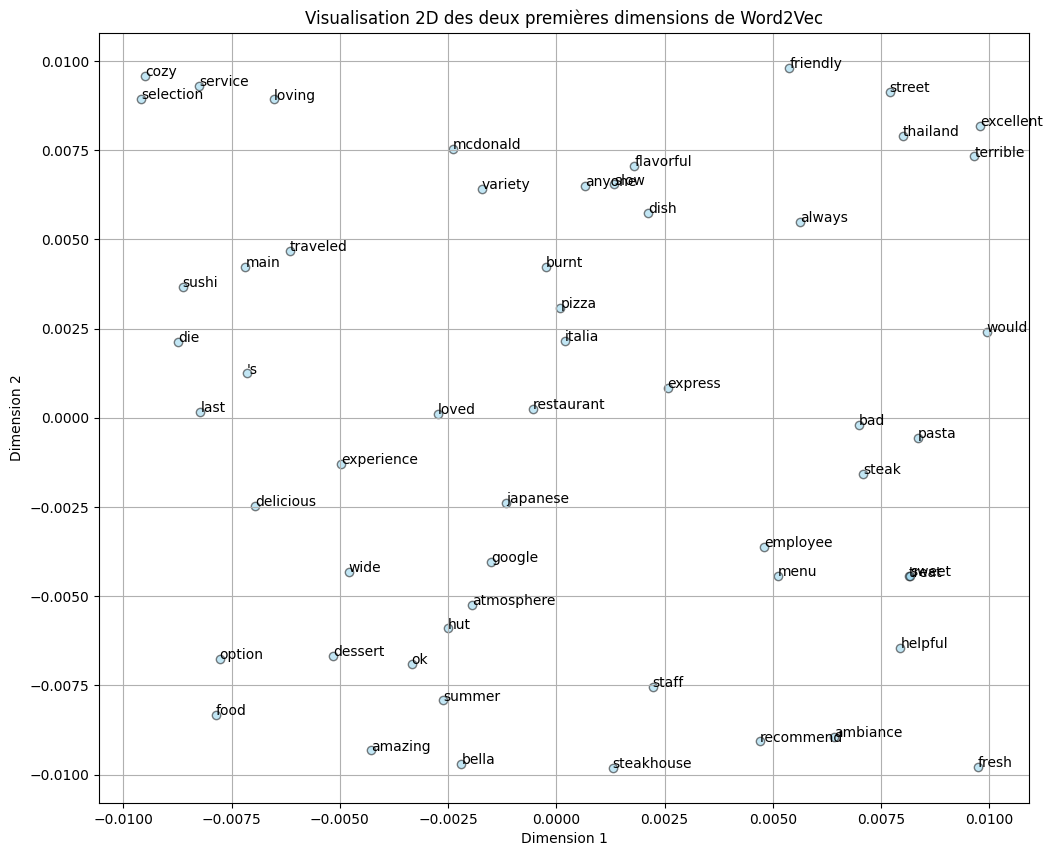

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_word_embeddings(model, words=None):
    """Affiche les deux premières dimensions des vecteurs de mots."""
    if words is None:
        words = list(model.wv.index_to_key)

    # Récupérer les vecteurs pour les mots sélectionnés
    vectors = np.array([model.wv[word] for word in words])

    plt.figure(figsize=(12, 10))
    # On trace uniquement les deux premières dimensions (0 et 1) sur 100
    plt.scatter(vectors[:, 0], vectors[:, 1], alpha=0.5, edgecolors='k', c='skyblue')

    # Ajouter les étiquettes de texte pour chaque point
    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors[i, 0], vectors[i, 1]), size=10)

    plt.title("Visualisation 2D des deux premières dimensions de Word2Vec")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.show()

# Appel de la fonction de visualisation avec le modèle entraîné
plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

### 2.5 Visualisation avancée avec PCA

Au lieu de simplement choisir deux dimensions arbitraires, nous utilisons l'algorithme PCA pour compresser l'espace vectoriel de 100D à 2D.

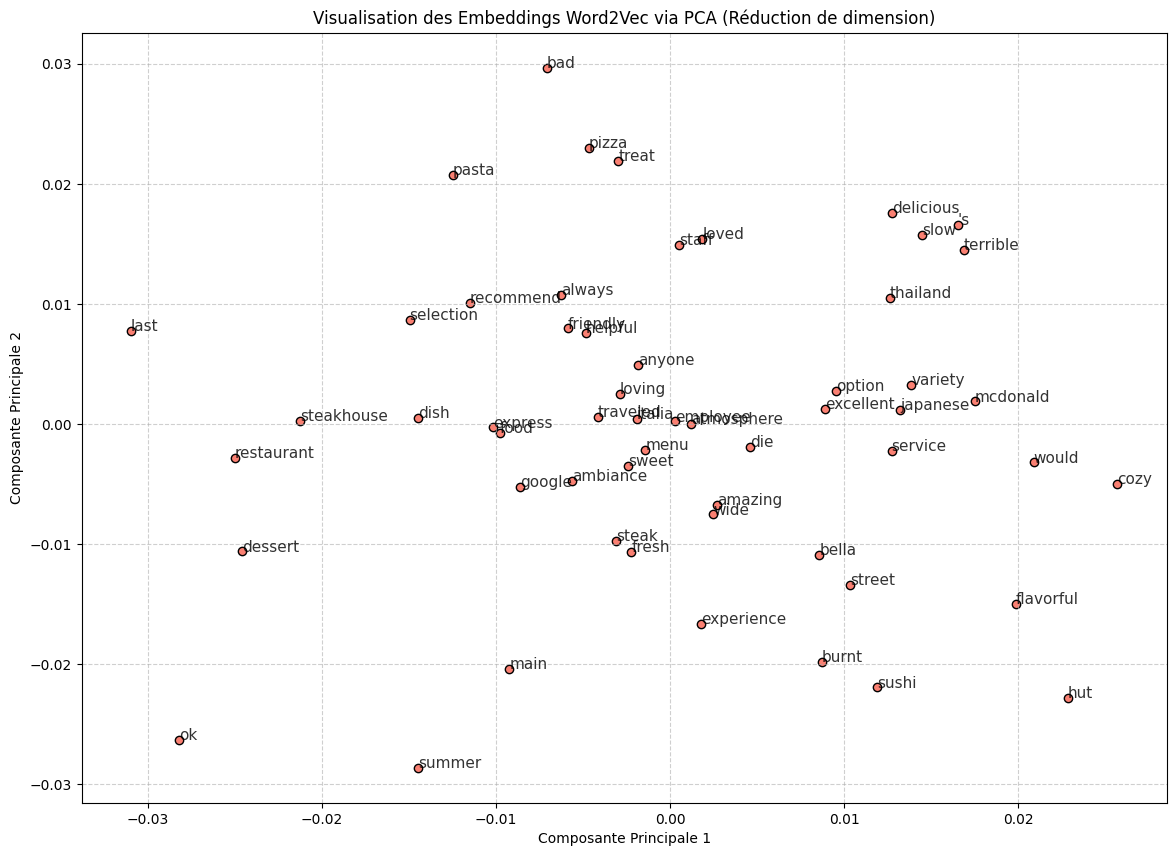

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_embeddings(model):
    # Récupérer tous les mots et leurs vecteurs
    words = list(model.wv.index_to_key)
    vectors = model.wv[words]

    # Appliquer la PCA pour passer de 100 dimensions à 2
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    # Création du graphique
    plt.figure(figsize=(14, 10))
    plt.scatter(result[:, 0], result[:, 1], c='salmon', edgecolors='k')

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), size=11, alpha=0.8)

    plt.title("Visualisation des Embeddings Word2Vec via PCA (Réduction de dimension)")
    plt.xlabel("Composante Principale 1")
    plt.ylabel("Composante Principale 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Affichage
plot_pca_embeddings(w2v_model)

### 2.6 Exploration de la similarité sémantique

Une des forces de Word2Vec est de pouvoir calculer la similarité cosinus entre les vecteurs. Voyons quels mots sont les plus proches de 'restaurant' dans notre petit espace vectoriel.

In [19]:
word_to_test = "restaurant"

if word_to_test in w2v_model.wv:
    print(f"Mots les plus similaires à '{word_to_test}':")
    similar_words = w2v_model.wv.most_similar(word_to_test, topn=5)
    for word, score in similar_words:
        print(f"- {word}: {score:.4f}")
else:
    print(f"Le mot '{word_to_test}' n'est pas dans le vocabulaire.")

Mots les plus similaires à 'restaurant':
- steakhouse: 0.2189
- dessert: 0.2162
- pasta: 0.1954
- ok: 0.1722
- summer: 0.1692


## Conclusion Générale

Dans ce notebook, nous avons parcouru les étapes essentielles d'un pipeline NLP :
1. **Prétraitement** : Nous avons vu comment nettoyer du texte pour réduire le bruit (minuscules, stopwords, lemmatisation).
2. **Extraction de caractéristiques (NER & POS)** :
    - Le **NER** est plus performant sur le texte **brut** car il utilise la casse et la ponctuation.
    - Le **POS Tagging** nous donne la structure grammaticale, utile pour comprendre le rôle de chaque mot.
3. **Word Embeddings** : Nous avons transformé des mots en vecteurs mathématiques avec **Word2Vec** et visualisé ces relations grâce à la **PCA**.

**Note** : Pour obtenir des résultats sémantiques robustes avec Word2Vec (comme des synonymes parfaits), il est nécessaire d'entraîner le modèle sur des millions de mots. Ici, avec 10 lignes, nous avons surtout illustré la méthode technique.

**Bravo, vous avez terminé l'exercice !**